# SentinelMail — Rule-Based DLP Benchmark

Evaluates `models/rule_based/RuleBasedDetector` (Microsoft Presidio) against the
ai4privacy validation split as a zero-training baseline for the ensemble benchmark.

In [1]:
import sys
from pathlib import Path

import pandas as pd
from datasets import load_dataset
from tqdm.auto import tqdm

REPO_ROOT = Path("..").resolve()
sys.path.insert(0, str(REPO_ROOT))

DATA_RAW = REPO_ROOT / "data" / "ai4privacy" / "raw"
RESULTS_DIR = REPO_ROOT / "evaluation" / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

from data.preprocessing import build_labels, LABEL_COLS
from evaluation import (
    compute_all_metrics,
    classify_errors,
    error_summary,
    plot_confusion_matrices,
    plot_per_label_bars,
    save_results,
    from_dataframe,
    from_dicts,
)

/Users/erelv/projects-chkp/final-project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Validation Split

In [2]:
ds = load_dataset("ai4privacy/pii-masking-300k", cache_dir=str(DATA_RAW))
val_en = ds["validation"].filter(lambda x: x["language"] == "English")
val_df = val_en.to_pandas()
print(f"Validation rows (English): {len(val_df):,}")

Validation rows (English): 7,946


## 2. Build Ground-Truth Labels

In [3]:
label_df = val_df["privacy_mask"].apply(build_labels).apply(pd.Series)
val_df = pd.concat([val_df, label_df], axis=1)

print("Ground-truth label distribution (validation, EN):")
print(val_df[LABEL_COLS].sum().to_string())

Ground-truth label distribution (validation, EN):
benign           908
PII             7038
financial       1529
confidential    3632


## 3. Run Rule-Based Detector

In [4]:
from models.rule_based import RuleBasedDetector

detector = RuleBasedDetector(score_threshold=0.4)
print("Detector loaded. Running on validation set...")

predictions = []
for text in tqdm(val_df["source_text"], desc="Detecting"):
    predictions.append(detector.predict(text))

pred_df = pd.DataFrame(predictions)
print("Predicted label distribution:")
print(pred_df[LABEL_COLS].sum().to_string())

Detector loaded. Running on validation set...


Detecting: 100%|██████████| 7946/7946 [01:50<00:00, 71.93it/s]

Predicted label distribution:
benign          1098
PII             6848
financial        791
confidential    2826


## 4. Per-Label Metrics

In [5]:
y_true = from_dataframe(val_df)
y_pred = from_dicts(predictions)

metrics = compute_all_metrics(y_true, y_pred)

print(f"Macro-F1: {metrics['macro_f1']:.4f}  "
      f"(95% CI: [{metrics['macro_f1_ci']['lower']:.4f}, {metrics['macro_f1_ci']['upper']:.4f}])")
print()

import pandas as pd
pd.DataFrame(metrics["per_label"]).T.round(4)

Macro-F1: 0.7528  (95% CI: [0.7430, 0.7623])



,precision,recall,f1,support
benign,0.5528,0.6685,0.6052,908.0
PII,0.9560,0.9302,0.9430,7038.0
financial,0.9621,0.4977,0.6560,1529.0
confidential,0.9222,0.7175,0.8071,3632.0


## 5. Confusion Matrices

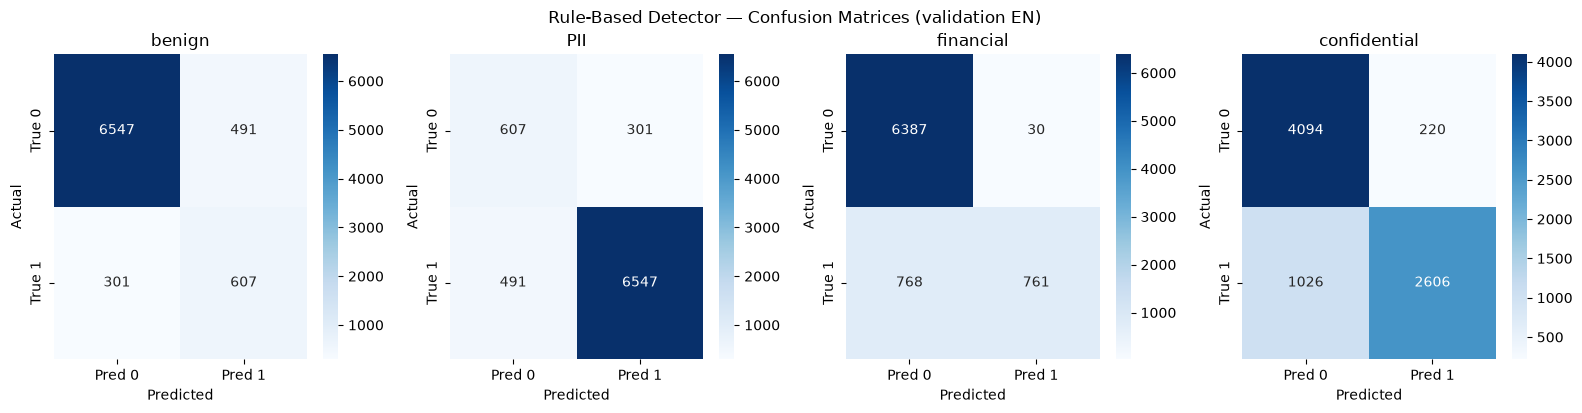

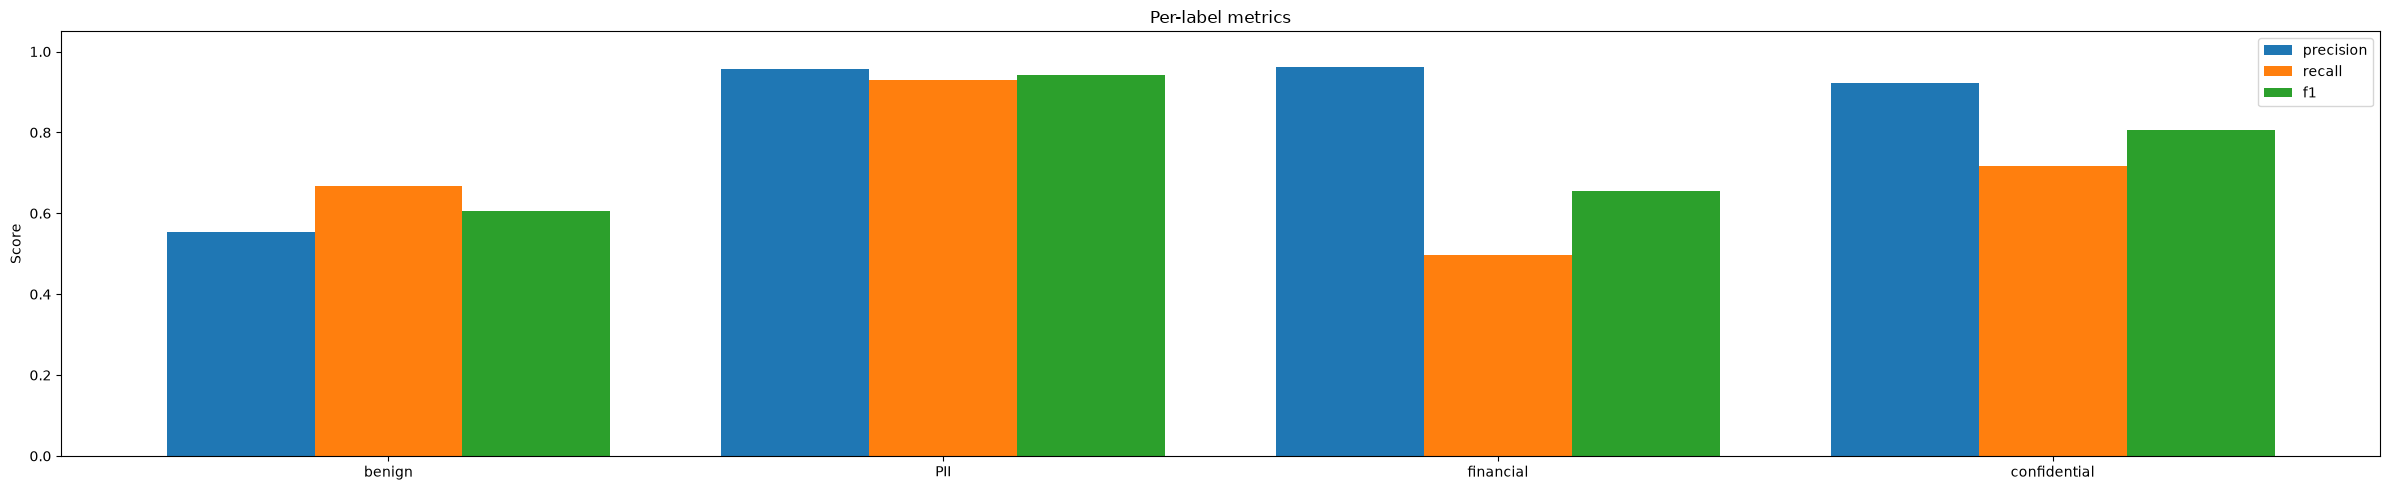

In [6]:
import matplotlib.pyplot as plt

cms, fig = plot_confusion_matrices(y_true, y_pred, return_fig=True)
fig.suptitle("Rule-Based Detector — Confusion Matrices (validation EN)", y=1.02)
plt.show()

_, bar_fig = plot_per_label_bars(metrics, return_fig=True)
plt.show()

## 6. Error Analysis

In [7]:
texts = val_df["source_text"].tolist()

error_results = classify_errors(
    texts, y_true, y_pred,
    explain_fn=detector.explain,
    max_examples=20,
)

summary_df = error_summary(error_results)
print("Error counts by type and label:")
display(summary_df.pivot(index="error_type", columns="label", values="count").fillna(0).astype(int))

print("\n--- Sample FP Negations ---")
for r in error_results["FP_negation"][:5]:
    print(f"  [{r['label']}] {r['text_snippet'][:100]}")
    if r["explain"]:
        print(f"    detections: {[(h['entity_type'], h['text_snippet']) for h in r['explain']]}")

print("\n--- Sample FN Obfuscated ---")
for r in error_results["FN_obfuscated"][:5]:
    print(f"  [{r['label']}] {r['text_snippet'][:100]}")

Error counts by type and label:


label,PII,benign,confidential,financial
error_type,,,,
FN_implicit,1,1,20,20
FN_obfuscated,4,0,20,20
FP_hypothetical,7,6,7,1
FP_negation,20,20,20,1
other_FN,20,20,20,20
other_FP,20,20,20,20



--- Sample FP Negations ---
  [PII] ectors conducted thorough inspections, ensuring compliance with health and safety standards.
- No ma
    detections: [('ORGANIZATION', 'the Health and Safety Inspections'), ('LOCATION', 'Great Britain')]
  [confidential] nformation:**

1. Participant from Great Britain:
   - First Name: Not Applicable
   - Last Name: No
    detections: [('IP_ADDRESS', '1fb3:ead5:de9d:79e3:8ac6:9993:c788:8278'), ('LOCATION', 'Great Britain'), ('LOCATION', 'United Kingdom'), ('PERSON', 'Norton'), ('LOCATION', 'Great Britain'), ('US_DRIVER_LICENSE', 'c788')]
  [confidential] le
   - Country: GB
   - Building Number: 344
   - Street: Stratfield Saye Road
   - City: Reading S
    detections: [('IP_ADDRESS', 'a732:a593:4d74:7282:6826:3ca2:3a70:16b7'), ('ORGANIZATION', 'GB\n   - Building Number'), ('PERSON', 'Stratfield Saye\n   - State'), ('LOCATION', 'Great Britain'), ('ORGANIZATION', 'GB\n   - Building Number'), ('ORGANIZATION', 'Gainsborough Somerby'), ('US_DRIVER_LICE

## 7. Save Results

In [8]:
out_path = RESULTS_DIR / "rule_based_metrics.json"

save_results(
    metrics,
    path=out_path,
    model_name="rule_based_presidio",
    n_samples=len(val_df),
    threshold=detector.score_threshold,
    extra_metadata={"score_threshold": detector.score_threshold},
)

print(f"Saved to {out_path}")

Saved to /Users/erelv/projects-chkp/final-project/evaluation/results/rule_based_metrics.json
